In [ ]:
pip install pandas matplotlib numpy scikit-learn


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## West Midlands Fire Service data
path='/content/drive/MyDrive/Seti/Fire/Code/'
data= pd.read_excel(path+'WMFS_dwel_fires.xlsx', parse_dates=['date_time'])

## Missing Values
missing = data.isnull().sum()
# Drop columns with more than 1000 missing values
data = data[missing[missing < 1000].index]
# Drop rows with missing values in the remaining columns
data.dropna(inplace=True)

## IMD
IMD=pd.read_excel(path+'File_5_-_IoD2019_Scores.xlsx', sheet_name='IoD2019 Scores')

## LSOAs
LSOA= pd.read_excel(path+"LSOA11_WD21_LAD21_EW_LU_V2.xlsx")
LSOA = LSOA[['LSOA11CD', 'WD21NM']]

## Population
# Population Estimates in the West Midlands region by Single Year of Age and Sex, Persons
population = pd.read_excel(path+"SAPE22DT10e-mid-2019-coa-unformatted-syoa-estimates-west-midlands.xlsx",
                           sheet_name="Mid-2019 Persons", skiprows=4)

# Extract population data for ages 16 to 64
population['16-64 Population'] = population.iloc[:, 19:67].sum(axis=1)

# Aggregate population data to LSOA level
pop_lsoa = population.groupby('LSOA11CD').agg({'All Ages': 'sum', '16-64 Population': 'sum'}).reset_index()


Mounted at /content/drive


In [ ]:
## Merge IMD, LSOA, Population
# *1* Join IMD and LSOA datasets
imd_ward = pd.merge(IMD, LSOA, left_on='LSOA code (2011)', right_on='LSOA11CD', how='inner')

# *2* Join IMD_Ward and population datasets
imd_population = pd.merge(imd_ward, pop_lsoa, on='LSOA11CD')

In [ ]:
imd_ward.head()

,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Income Score (rate),Employment Score (rate),"Education, Skills and Training Score",Health Deprivation and Disability Score,Crime Score,...,Income Deprivation Affecting Children Index (IDACI) Score (rate),Income Deprivation Affecting Older People (IDAOPI) Score (rate),Children and Young People Sub-domain Score,Adult Skills Sub-domain Score,Geographical Barriers Sub-domain Score,Wider Barriers Sub-domain Score,Indoors Sub-domain Score,Outdoors Sub-domain Score,LSOA11CD,WD21NM
0,E01000001,City of London 001A,E09000001,City of London,6.208,0.007,0.010,0.024,-1.654,-2.012,...,0.006,0.012,-2.107,0.032,-0.430,3.587,0.006,1.503,E01000001,Aldersgate
1,E01000002,City of London 001B,E09000001,City of London,5.143,0.034,0.027,0.063,-1.115,-2.343,...,0.037,0.030,-1.907,0.034,-1.060,3.231,-0.410,1.196,E01000002,Cripplegate
2,E01000003,City of London 001C,E09000001,City of London,19.402,0.086,0.086,5.804,-0.102,-1.032,...,0.052,0.128,-0.292,0.142,-0.691,5.173,-0.054,2.207,E01000003,Cripplegate
3,E01000005,City of London 001E,E09000001,City of London,28.652,0.211,0.136,22.260,-0.121,-1.317,...,0.209,0.322,0.338,0.321,-1.167,5.361,-0.604,1.769,E01000005,Portsoken
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,19.837,0.117,0.059,14.798,-0.359,-0.147,...,0.155,0.162,-0.366,0.325,-0.400,5.590,0.110,0.969,E01000006,Abbey


In [ ]:
imd_population.columns

Index(['LSOA code (2011)', 'LSOA name (2011)',
       'Local Authority District code (2019)',
       'Local Authority District name (2019)',
       'Index of Multiple Deprivation (IMD) Score', 'Income Score (rate)',
       'Employment Score (rate)', 'Education, Skills and Training Score',
       'Health Deprivation and Disability Score', 'Crime Score',
       'Barriers to Housing and Services Score', 'Living Environment Score',
       'Income Deprivation Affecting Children Index (IDACI) Score (rate)',
       'Income Deprivation Affecting Older People (IDAOPI) Score (rate)',
       'Children and Young People Sub-domain Score',
       'Adult Skills Sub-domain Score',
       'Geographical Barriers Sub-domain Score',
       'Wider Barriers Sub-domain Score', 'Indoors Sub-domain Score',
       'Outdoors Sub-domain Score', 'LSOA11CD', 'WD21NM', 'All Ages',
       '16-64 Population'],
      dtype='object')

In [ ]:
# Rename and select relevant columns
imd_population = imd_population[['Local Authority District name (2019)',
                                 'WD21NM', 'LSOA code (2011)',
                                 'Index of Multiple Deprivation (IMD) Score', 'Income Score (rate)','Employment Score (rate)',
                                 'Education, Skills and Training Score','Health Deprivation and Disability Score', 'Crime Score',
                                 'Barriers to Housing and Services Score', 'Living Environment Score',
                                 'All Ages', '16-64 Population']]

imd_population.columns = ['District', 'Ward', 'LSOA', 'IMD_Score', 'Income Score (rate)','Employment Score (rate)',
                                 'Education, Skills and Training Score','Health Deprivation and Disability Score', 'Crime Score',
                                 'Barriers to Housing and Services Score', 'Living Environment Score','Population', '16-64 Population']

In [ ]:
imd_population.head()

,District,Ward,LSOA,IMD_Score,Income Score (rate),Employment Score (rate),"Education, Skills and Training Score",Health Deprivation and Disability Score,Crime Score,Barriers to Housing and Services Score,Living Environment Score,Population,16-64 Population
0,Birmingham,Yardley West & Stechford,E01008881,41.179,0.232,0.191,31.443,0.605,0.733,26.689,53.329,1733,1023
1,Birmingham,Tyseley & Hay Mills,E01008882,59.693,0.311,0.249,49.584,1.374,0.739,40.006,57.869,1829,1101
2,Birmingham,Tyseley & Hay Mills,E01008883,38.636,0.230,0.145,34.866,0.648,0.208,32.284,56.120,2136,1327
3,Birmingham,Tyseley & Hay Mills,E01008884,44.315,0.273,0.167,35.441,0.474,0.113,40.686,62.306,2242,1356
4,Birmingham,South Yardley,E01008885,22.921,0.102,0.073,24.280,-0.084,0.125,35.439,45.380,1309,798


In [ ]:
# Filter datasets to only include Birmingham
imd_population = imd_population[imd_population['District'] == 'Birmingham']

In [ ]:
# Filter the data to only include rows where the district is Birmingham
birmingham_data = data[data['district'] == 'Birmingham']

# Group by borough and extract unique wards for each borough
wards_by_borough = birmingham_data.groupby('borough')['ward'].unique()
wards_by_borough = wards_by_borough.reset_index()

wards_by_borough.head()

,borough,ward
0,Birmingham North,"[North Edgbaston, Holyhead, Handsworth, Sutton..."
1,Birmingham South,"[Bournville & Cotteridge, Weoley & Selly Oak, ..."


In [ ]:

# Explode the `wards_by_borough` DataFrame
wards_by_borough_exploded = wards_by_borough.explode('ward').reset_index(drop=True)

# Merge the `imd_population` DataFrame with the `wards_by_borough_exploded` DataFrame
imd_population_df = pd.merge(imd_population, wards_by_borough_exploded, left_on='Ward', right_on='ward', how='left')

# Optionally, drop the 'ward' column from the merged DataFrame if it's redundant
imd_population_df.drop(columns=['ward'], inplace=True)

# Display the resulting DataFrame
imd_population_df.head()


,District,Ward,LSOA,IMD_Score,Income Score (rate),Employment Score (rate),"Education, Skills and Training Score",Health Deprivation and Disability Score,Crime Score,Barriers to Housing and Services Score,Living Environment Score,Population,16-64 Population,borough
0,Birmingham,Yardley West & Stechford,E01008881,41.179,0.232,0.191,31.443,0.605,0.733,26.689,53.329,1733,1023,Birmingham South
1,Birmingham,Tyseley & Hay Mills,E01008882,59.693,0.311,0.249,49.584,1.374,0.739,40.006,57.869,1829,1101,Birmingham South
2,Birmingham,Tyseley & Hay Mills,E01008883,38.636,0.230,0.145,34.866,0.648,0.208,32.284,56.120,2136,1327,Birmingham South
3,Birmingham,Tyseley & Hay Mills,E01008884,44.315,0.273,0.167,35.441,0.474,0.113,40.686,62.306,2242,1356,Birmingham South
4,Birmingham,South Yardley,E01008885,22.921,0.102,0.073,24.280,-0.084,0.125,35.439,45.380,1309,798,Birmingham South


In [ ]:
# Calculate total population and 16-64 population per borough
borough_info = imd_population_df.groupby('borough').agg({
    'District': 'first',
    'IMD_Score': 'mean',
    'Income Score (rate)': 'mean',
    'Employment Score (rate)': 'mean',
    'Education, Skills and Training Score': 'mean',
    'Health Deprivation and Disability Score': 'mean',
    'Crime Score': 'mean',
    'Barriers to Housing and Services Score':'mean',
    'Living Environment Score':'mean',
    'Population': 'sum',
    '16-64 Population': 'sum',
    'LSOA': 'nunique',
    'Ward': 'nunique'
}).reset_index()
borough_info.rename(columns={'IMD_Score': 'IMD_Score_borough_avg', 'Income Score (rate)': 'Income Score (rate)_borough_avg',
    'Employment Score (rate)': 'Employment Score (rate)_borough_avg',
    'Education, Skills and Training Score': 'Education, Skills and Training Score_borough_avg',
    'Health Deprivation and Disability Score': 'Health Deprivation and Disability Score_borough_avg',
    'Crime Score': 'Crime Score_borough_avg',
    'Barriers to Housing and Services Score':'Barriers to Housing Score_borough_avg',
    'Living Environment Score':'Living Environment Score_borough_avg'}, inplace=True)

In [ ]:
borough_info.head()

,borough,District,IMD_Score_borough_avg,Income Score (rate)_borough_avg,Employment Score (rate)_borough_avg,"Education, Skills and Training Score_borough_avg",Health Deprivation and Disability Score_borough_avg,Crime Score_borough_avg,Barriers to Housing Score_borough_avg,Living Environment Score_borough_avg,Population,16-64 Population,LSOA,Ward
0,Birmingham North,Birmingham,38.556741,0.223503,0.158269,33.711102,0.651244,0.277809,31.824843,41.053022,590571,376292,324,36
1,Birmingham South,Birmingham,36.632686,0.212746,0.152889,28.909041,0.688251,0.405781,30.519956,40.139530,551245,348339,315,33


In [ ]:
df_year = data[data['year'].isin([2018, 2019])]

# Fire per borough
borough_frq= df_year['borough'].value_counts().reset_index()
borough_frq.columns = ['borough', 'Number of Fires']
borough_info = pd.merge(borough_info, borough_frq, on='borough')
borough_info.head()

,borough,District,IMD_Score_borough_avg,Income Score (rate)_borough_avg,Employment Score (rate)_borough_avg,"Education, Skills and Training Score_borough_avg",Health Deprivation and Disability Score_borough_avg,Crime Score_borough_avg,Barriers to Housing Score_borough_avg,Living Environment Score_borough_avg,Population,16-64 Population,LSOA,Ward,Number of Fires
0,Birmingham North,Birmingham,38.556741,0.223503,0.158269,33.711102,0.651244,0.277809,31.824843,41.053022,590571,376292,324,36,858
1,Birmingham South,Birmingham,36.632686,0.212746,0.152889,28.909041,0.688251,0.405781,30.519956,40.139530,551245,348339,315,33,775


In [ ]:
# Calculate fire incidents per 100,000 population
borough_info['Fires per 100k Population'] = (borough_info['Number of Fires'] / borough_info['Population']) * 100000
borough_info['Fires per 100k (16-64 year) Population'] = (borough_info['Number of Fires'] / borough_info['16-64 Population']) * 100000

# Sort by fire incidents per 100,000 population in descending order
borough_info.sort_values(by='Fires per 100k Population', ascending=False, inplace=True)

# Display the updated district_info dataframe
borough_info


,borough,District,IMD_Score_borough_avg,Income Score (rate)_borough_avg,Employment Score (rate)_borough_avg,"Education, Skills and Training Score_borough_avg",Health Deprivation and Disability Score_borough_avg,Crime Score_borough_avg,Barriers to Housing Score_borough_avg,Living Environment Score_borough_avg,Population,16-64 Population,LSOA,Ward,Number of Fires,Fires per 100k Population,Fires per 100k (16-64 year) Population
0,Birmingham North,Birmingham,38.556741,0.223503,0.158269,33.711102,0.651244,0.277809,31.824843,41.053022,590571,376292,324,36,858,145.283124,228.014414
1,Birmingham South,Birmingham,36.632686,0.212746,0.152889,28.909041,0.688251,0.405781,30.519956,40.139530,551245,348339,315,33,775,140.590844,222.484419


In [ ]:
borough_info.to_excel( 'borough_info.xlsx', index=False)

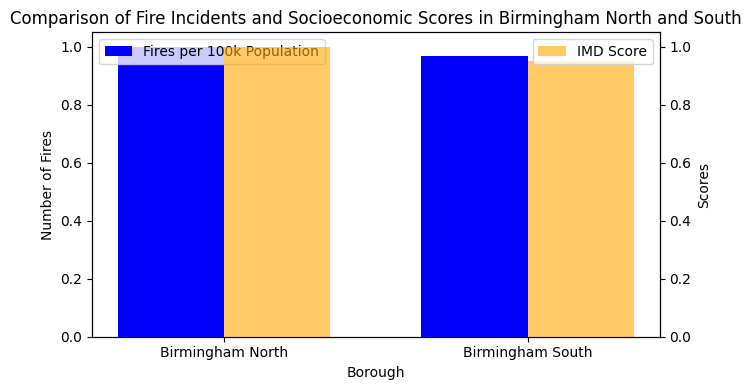

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
borough_info['IMD_Score_normalized'] = borough_info['IMD_Score_borough_avg'] / borough_info['IMD_Score_borough_avg'].max()
borough_info['Fires per 100k Population_normalized'] = borough_info['Fires per 100k Population'] / borough_info['Fires per 100k Population'].max()

fig, ax1 = plt.subplots(figsize=(7, 4))

# Plot fire incidents as bars
bar_width = 0.35
index = range(len(borough_info['borough']))
ax1.bar(index, borough_info['Fires per 100k Population_normalized'], bar_width, label='Fires per 100k Population', color='blue')

# Set up the second y-axis
ax2 = ax1.twinx()

# Plot the socioeconomic scores as bars
ax2.bar([i + bar_width for i in index], borough_info['IMD_Score_normalized'], bar_width, label='IMD Score', color='orange', alpha=0.6)

#ax2.bar([i + bar_width for i in index], borough_info['Income Score (rate)_borough_avg'], bar_width, label='Income Score', color='green', alpha=0.6)
#ax2.bar([i + bar_width for i in index], borough_info['Employment Score (rate)_borough_avg'], bar_width, label='Employment Score', color='red', alpha=0.6)

# Setting labels and titles
ax1.set_xlabel('Borough')
ax1.set_ylabel('Number of Fires')
ax2.set_ylabel('Scores')

# X-axis labels
ax1.set_xticks([i + bar_width / 2 for i in index])
ax1.set_xticklabels(borough_info['borough'])

# Create legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show plot
plt.title('Comparison of Fire Incidents and Socioeconomic Scores in Birmingham North and South')
plt.tight_layout()
plt.show()


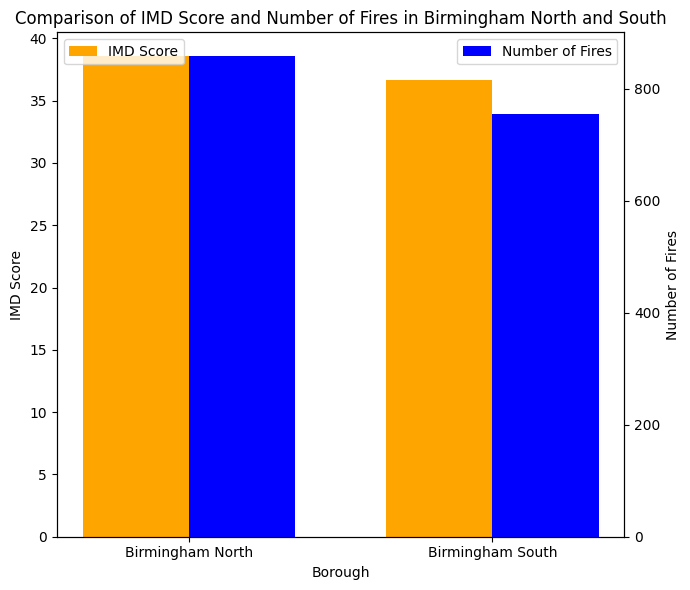

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sample data
data = {
    'borough': ['Birmingham North', 'Birmingham South'],
    'IMD_Score_borough_avg': [38.556741, 36.632686],
    'Number of Fires': [858, 755]
}

df = pd.DataFrame(data)

# Plotting
fig, ax1 = plt.subplots(figsize=(7, 6))

bar_width = 0.35
index = np.arange(len(df['borough']))

# Plot IMD Score on the primary axis
ax1.bar(index, df['IMD_Score_borough_avg'], bar_width, label='IMD Score', color='orange')

# Set up the second y-axis for Number of Fires
ax2 = ax1.twinx()
ax2.bar(index + bar_width, df['Number of Fires'], bar_width, label='Number of Fires', color='blue')

# Setting labels and titles
ax1.set_xlabel('Borough')
ax1.set_ylabel('IMD Score')
ax2.set_ylabel('Number of Fires')
ax1.set_title('Comparison of IMD Score and Number of Fires in Birmingham North and South')

# X-axis labels
ax1.set_xticks(index + bar_width / 2)
ax1.set_xticklabels(df['borough'])

# Create legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show plot
plt.tight_layout()
plt.show()


#In data az koja umade?

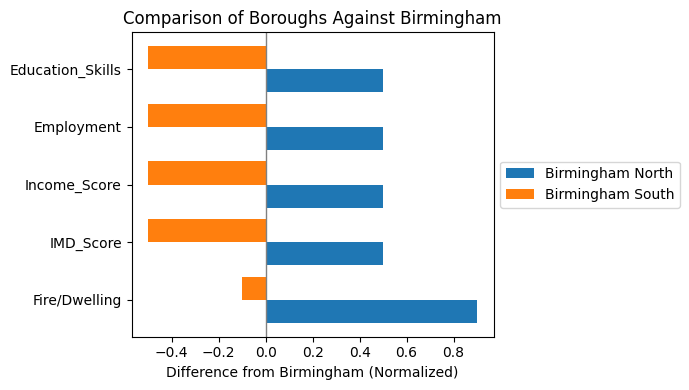

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Manually creating the DataFrame from the visible data in the image
dt = {
    'Region': ['Birmingham North', 'Birmingham South', 'Birmingham'],
    'Fire/Dwelling': [0.00375, 0.00365, 0.00366],
    'IMD_Score': [38.720407, 36.794013, 37.75721],
    'Income_Score': [0.226888, 0.212867, 0.2198775],
    'Employment': [0.160993, 0.153169, 0.157081],
    'Education_Skills': [34.12417, 29.573226, 31.846898]
}

# Creating the DataFrame
df = pd.DataFrame(dt)

# Normalizing the data (excluding the 'Region' column)
scaler = MinMaxScaler()
df_normalized = df.copy()
df_normalized.iloc[:, 1:] = scaler.fit_transform(df.iloc[:, 1:])

# Set 'Birmingham' as the reference baseline
baseline_normalized = df_normalized[df_normalized['Region'] == 'Birmingham'].iloc[0]

# Calculate the differences relative to the normalized baseline
df_diff_normalized = df_normalized.copy()
for col in ['Fire/Dwelling', 'IMD_Score', 'Income_Score', 'Employment', 'Education_Skills']:
    df_diff_normalized[col] = df_normalized[col] - baseline_normalized[col]

# Remove the baseline row itself for the difference chart
df_diff_normalized = df_diff_normalized[df_diff_normalized['Region'] != 'Birmingham']

# Variables to plot
variables = ['Fire/Dwelling', 'IMD_Score', 'Income_Score', 'Employment', 'Education_Skills']

# Set up the plot
fig, ax = plt.subplots(figsize=(7, 4))

# Colors for the bars
colors = ['#1f77b4', '#ff7f0e']  # Use different colors for the two regions

# Plot horizontal bars for each variable
bar_width = 0.4
for i, region in enumerate(df_diff_normalized['Region']):
    ax.barh(np.arange(len(variables)) + i * bar_width, df_diff_normalized.loc[df_diff_normalized['Region'] == region, variables].values[0],
            height=bar_width, label=region, color=colors[i])

# Add the baseline (zero line)
ax.axvline(0, color='gray', linewidth=1)

# Add labels and title
ax.set_yticks(np.arange(len(variables)) + bar_width / 2)
ax.set_yticklabels(variables)
ax.set_xlabel('Difference from Birmingham (Normalized)')
ax.set_title('Comparison of Boroughs Against Birmingham')

# Add legend
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Show plot
plt.tight_layout()
plt.show()

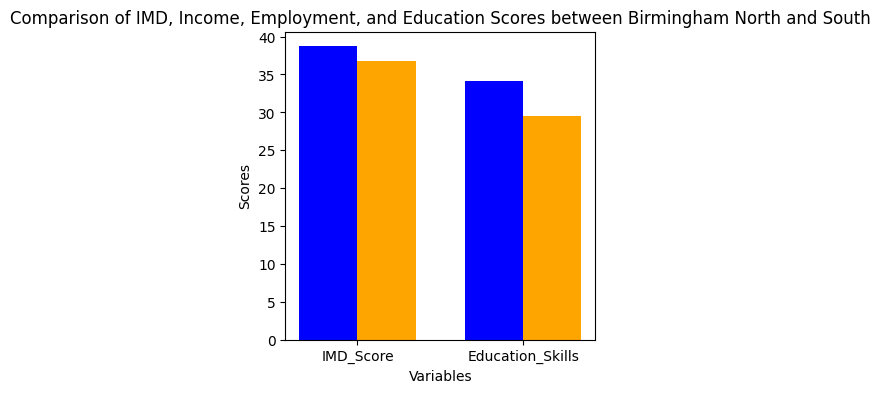

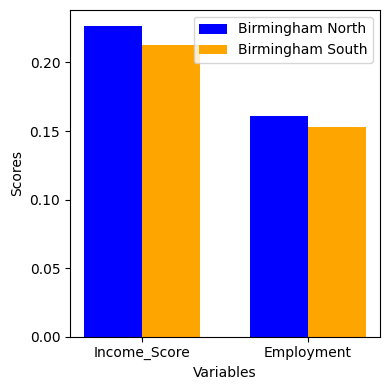

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Manually creating the DataFrame from the visible data
dt = {
    'Region': ['Birmingham North', 'Birmingham South'],
    'IMD_Score': [38.720407, 36.794013],
    'Income_Score': [0.226888, 0.212867],
    'Employment': [0.160993, 0.153169],
    'Education_Skills': [34.12417, 29.573226]
}

# Creating the DataFrame
df = pd.DataFrame(dt)

# Variables to plot
variables = ['IMD_Score', 'Education_Skills']
bar_width = 0.35
index = np.arange(len(variables))

# Set up the plot
fig, ax = plt.subplots(figsize=(4, 4))

# Plot for Birmingham North
ax.bar(index, df.loc[df['Region'] == 'Birmingham North', variables].values[0], bar_width, label='Birmingham North', color='blue')

# Plot for Birmingham South
ax.bar(index + bar_width, df.loc[df['Region'] == 'Birmingham South', variables].values[0], bar_width, label='Birmingham South', color='orange')

# Add labels and title
ax.set_xlabel('Variables')
ax.set_ylabel('Scores')
ax.set_title('Comparison of IMD, Income, Employment, and Education Scores between Birmingham North and South')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(variables)



# Variables to plot
variables = ['Income_Score', 'Employment']
bar_width = 0.35
index = np.arange(len(variables))

# Set up the plot
fig, ax = plt.subplots(figsize=(4, 4))

# Plot for Birmingham North
ax.bar(index, df.loc[df['Region'] == 'Birmingham North', variables].values[0], bar_width, label='Birmingham North', color='blue')

# Plot for Birmingham South
ax.bar(index + bar_width, df.loc[df['Region'] == 'Birmingham South', variables].values[0], bar_width, label='Birmingham South', color='orange')

# Add labels and title
ax.set_xlabel('Variables')
ax.set_ylabel('Scores')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(variables)


# Add legend
ax.legend()

# Show plot
plt.tight_layout()
plt.show()


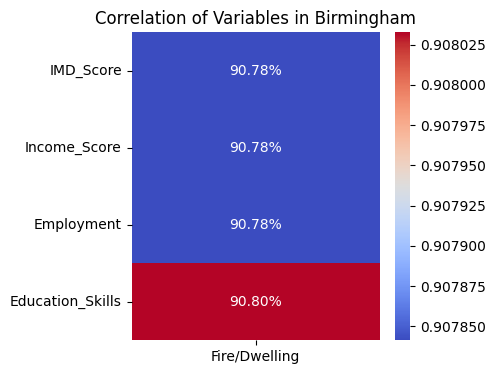

In [ ]:
import seaborn as sns

plt.figure(figsize=(4, 4))
sns.heatmap(pd.DataFrame(df_normalized.drop(columns=['Region']).corr().iloc[0,1:5]), cmap='coolwarm',annot=True,fmt=".2%")
plt.title('Correlation of Variables in Birmingham')
plt.show()

##inja##

# plot based on 100k Population

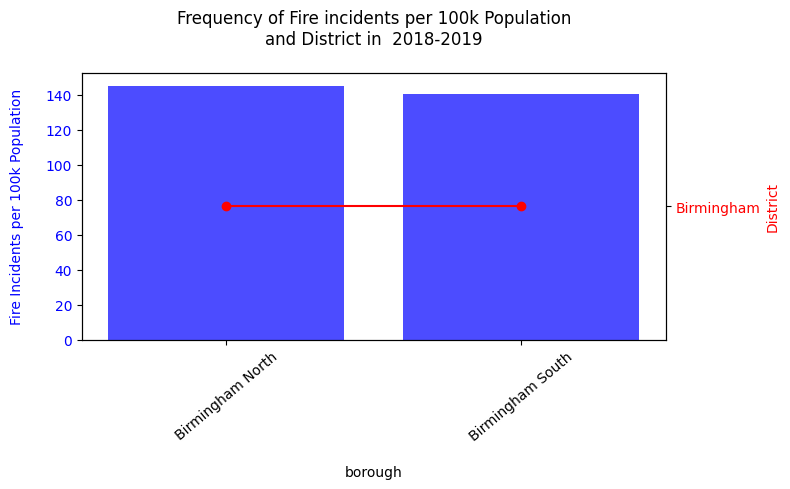

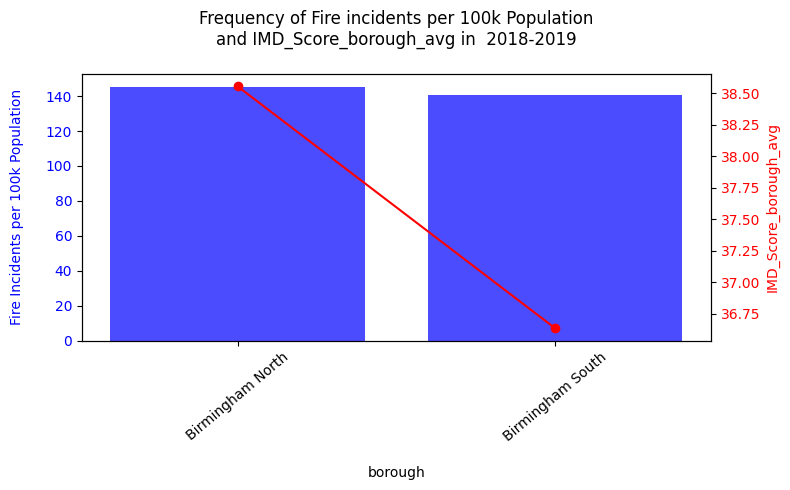

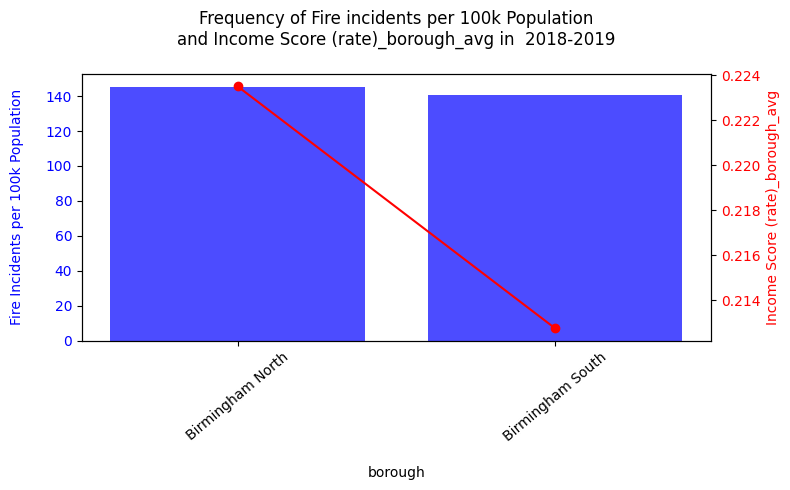

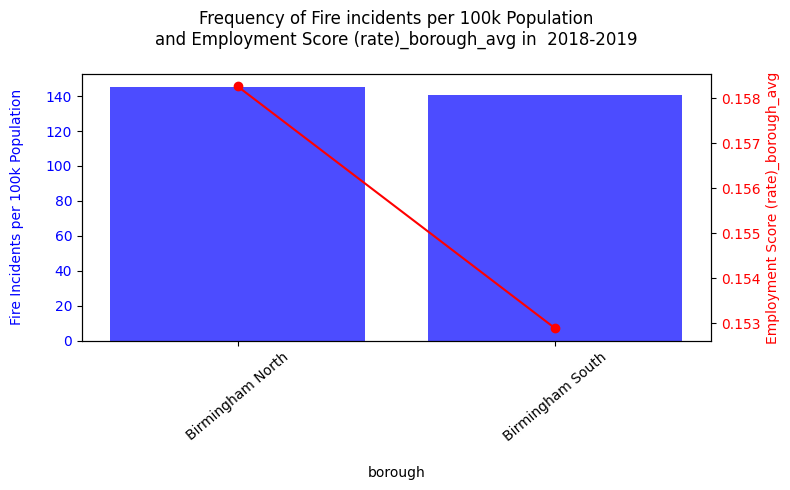

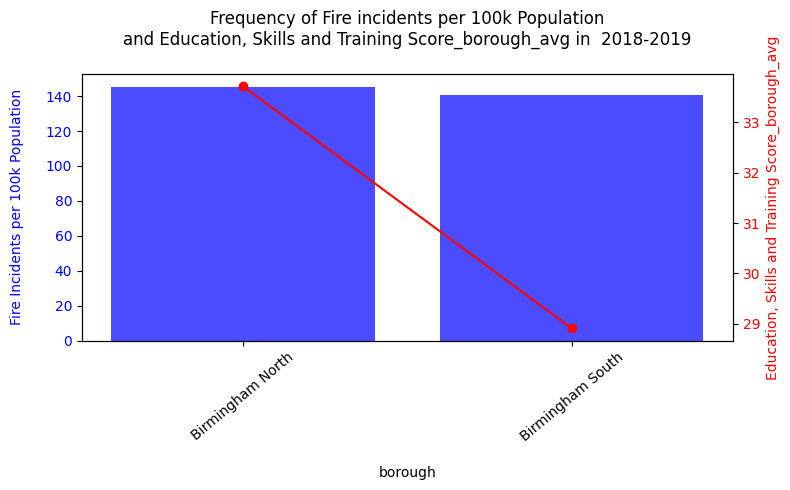

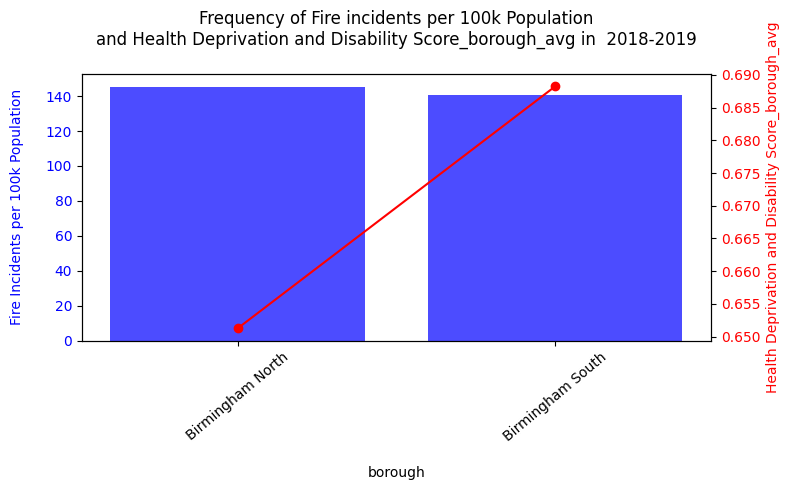

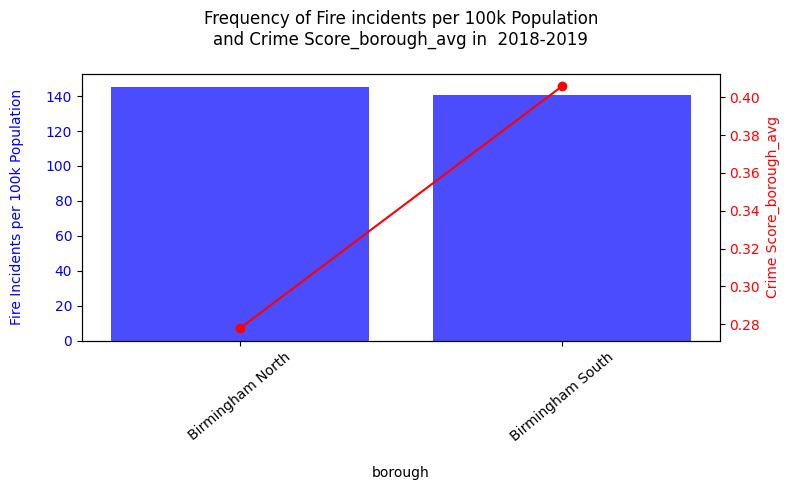

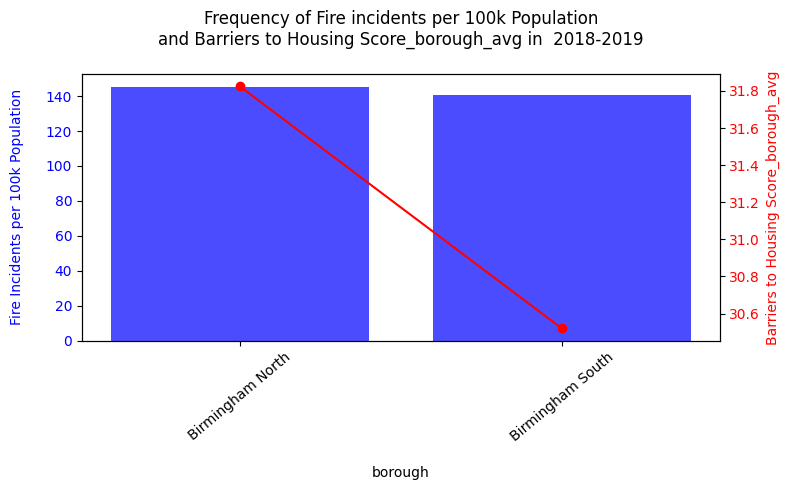

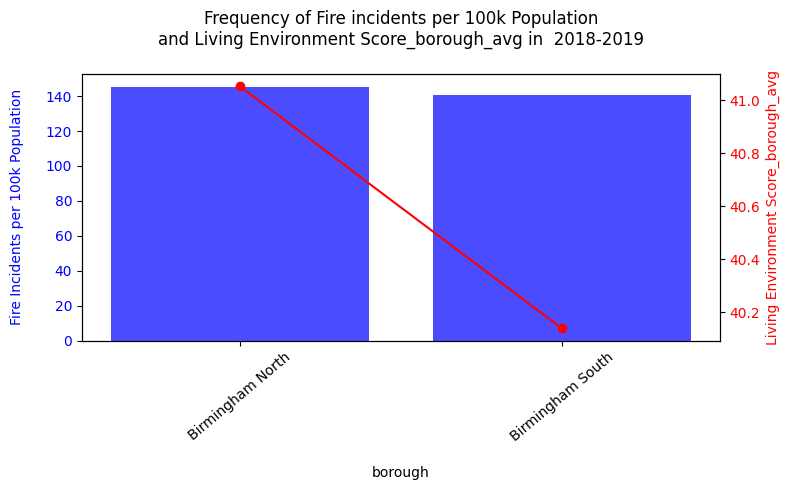

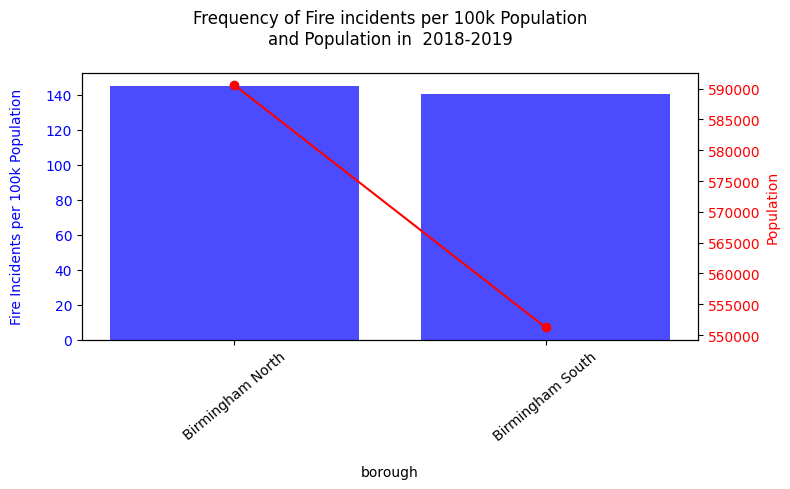

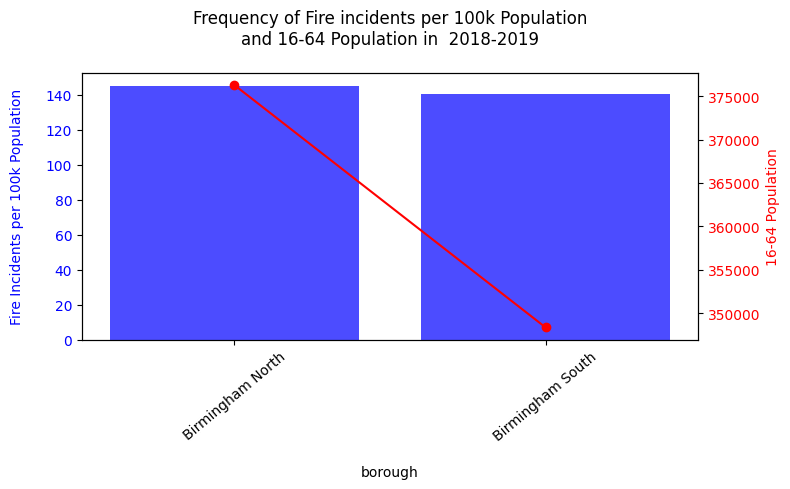

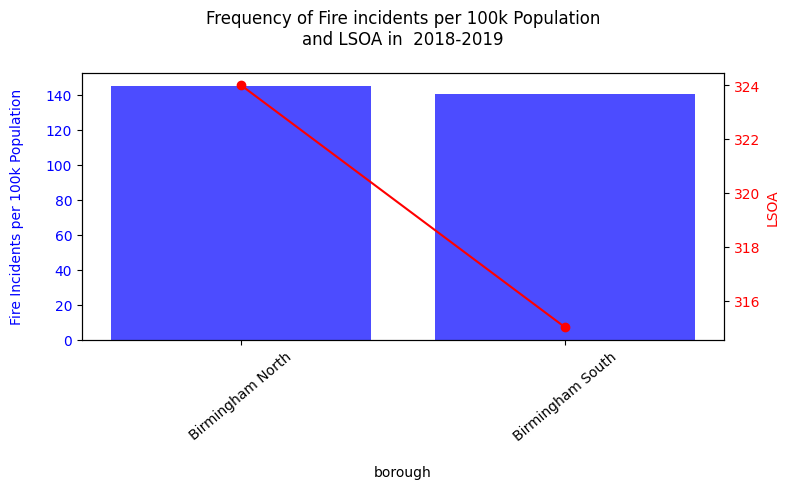

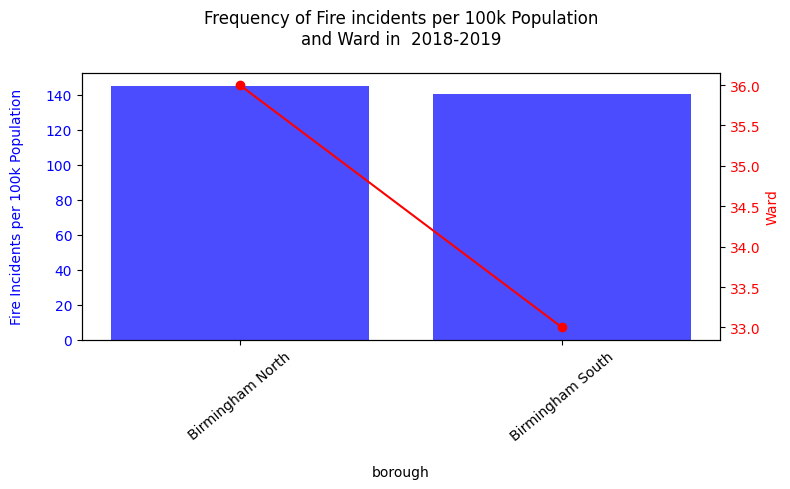

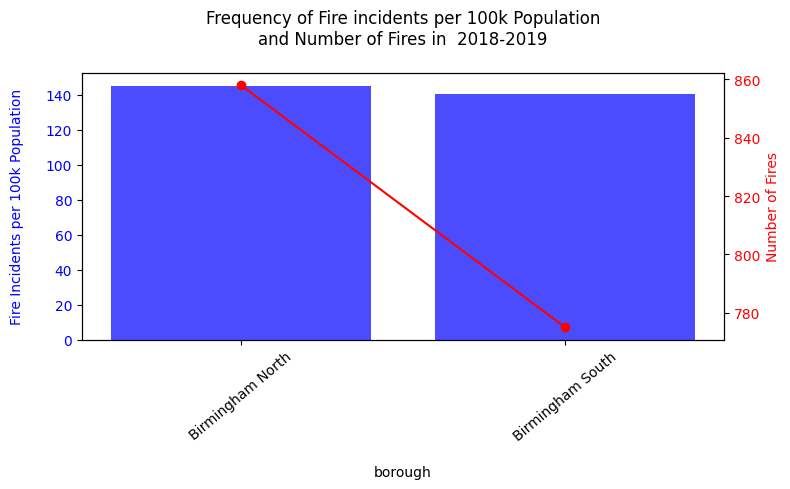

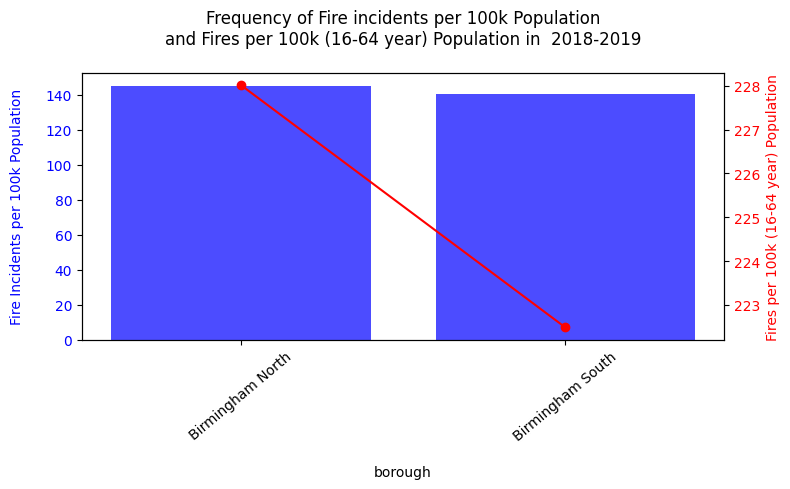

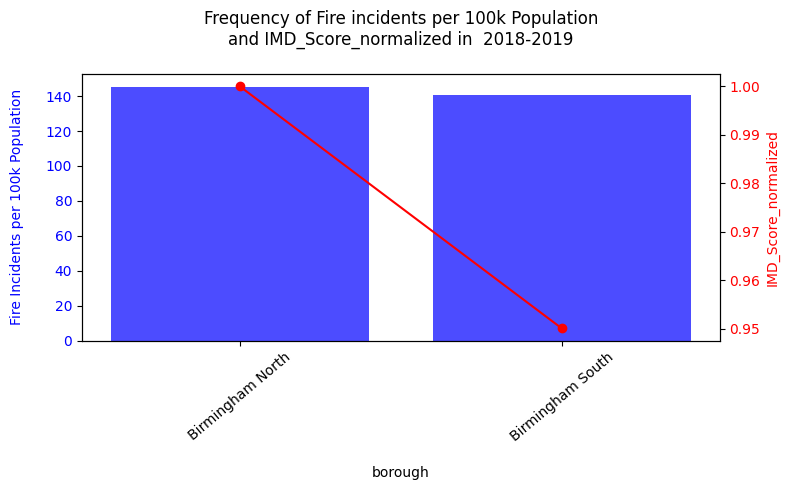

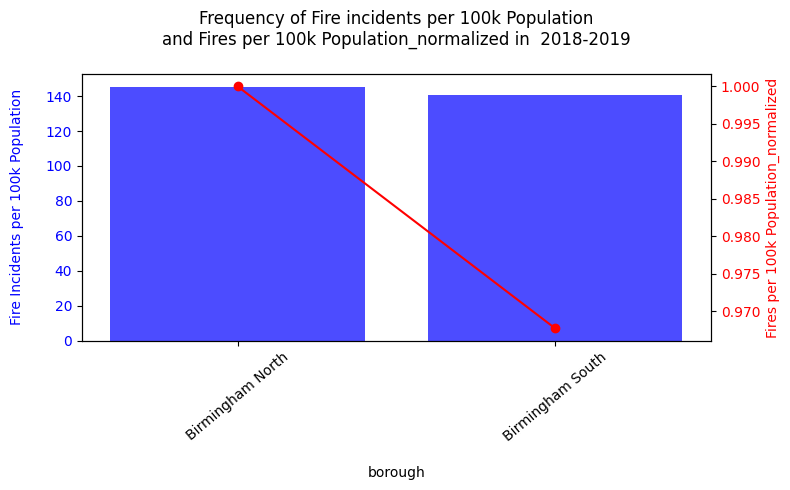

In [ ]:
# Plot
vars = [col for col in borough_info.columns if col not in ['borough', 'Fires per 100k Population']]

def plot_data(col_name):
    fig, ax1 = plt.subplots(figsize=(8, 5))
    # Fire
    ax1.bar(borough_info['borough'], borough_info['Fires per 100k Population'], color='b', alpha=0.7)
    ax1.set_xlabel('\nborough')
    ax1.set_ylabel('Fire Incidents per 100k Population\n', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    plt.xticks(rotation=40)
    # IMD
    ax2 = ax1.twinx()
    ax2.plot(borough_info['borough'], borough_info[col_name], color='r', marker='o')
    ax2.set_ylabel(col_name, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    plt.title('Frequency of Fire incidents per 100k Population\nand '+col_name+' in  2018-2019\n')
    fig.tight_layout()
    plt.show()

for col_name in vars:
    plot_data(col_name)

#Unemployed (Model Based)_Birmingham#

In [ ]:
unemployed_df= pd.read_excel(path+'Unemployed (Model Based)_Birmingham.xlsx')

In [ ]:
unemployed_df.head()

,Date,Birmingham,Birmingham(%),West Midlands(%),Great Britain(%)
0,Jan 2004-Dec 2004,38100,8.4,5.2,4.8
1,Apr 2004-Mar 2005,38700,8.4,5.1,4.7
2,Jul 2004-Jun 2005,39400,8.6,5.1,4.8
3,Oct 2004-Sep 2005,37200,8.3,5.0,4.8
4,Jan 2005-Dec 2005,38400,8.6,5.1,4.9


In [ ]:
# List of dates to filter
dates_to_extract = [
    "Jan 2017-Dec 2017", "Jan 2018-Dec 2018", "Jan 2019-Dec 2019",
    "Jan 2020-Dec 2020", "Jan 2021-Dec 2021", "Jan 2022-Dec 2022",
    "Jan 2023-Dec 2023"
]

# Extract rows where the 'Date' column contains the specified dates
filtered_unemployed = unemployed_df[unemployed_df['Date'].isin(dates_to_extract)]
filtered_unemployed.reset_index(drop=True, inplace=True)
# Format the 'Date' column to only show the year
filtered_unemployed['Date'] = filtered_unemployed['Date'].str.slice(start=4, stop=8)

# Display the filtered data
filtered_unemployed


<ipython-input-27-345b57245175>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_unemployed['Date'] = filtered_unemployed['Date'].str.slice(start=4, stop=8)


,Date,Birmingham,Birmingham(%),West Midlands(%),Great Britain(%)
0,2017,42500,8.3,5.3,4.4
1,2018,38600,7.3,4.7,4.2
2,2019,43900,8.2,4.8,3.9
3,2020,43400,8.1,5.4,4.7
4,2021,42800,8.0,5.0,4.4
5,2022,40200,7.3,4.6,3.6
6,2023,39000,7.2,4.4,3.7


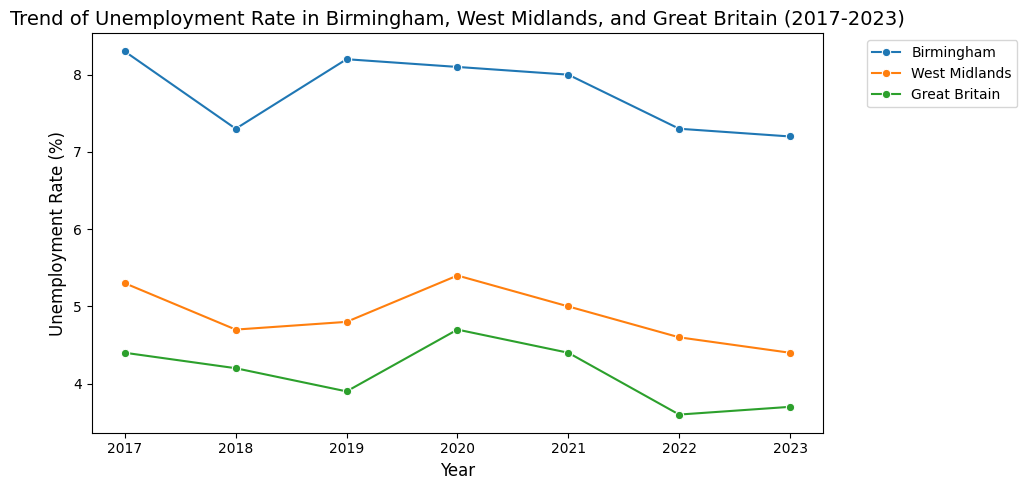

In [ ]:
# 1 Plotting
plt.figure(figsize=(10, 5))

sns.lineplot(data=filtered_unemployed, x='Date', y='Birmingham(%)', marker='o', label='Birmingham')
sns.lineplot(data=filtered_unemployed, x='Date', y='West Midlands(%)', marker='o', label='West Midlands')
sns.lineplot(data=filtered_unemployed, x='Date', y='Great Britain(%)', marker='o', label='Great Britain')

plt.title('Trend of Unemployment Rate in Birmingham, West Midlands, and Great Britain (2017-2023)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#fire-statistics-data-tables-fire0102-250724#

In [ ]:
Fire_incidents_xls = pd.read_excel(path + 'fire-statistics-data-tables-fire0102-250724.xlsx', sheet_name='FIRE0102_working',engine='openpyxl')


In [ ]:
england_rows = Fire_incidents_xls[Fire_incidents_xls.apply(lambda row: row.astype(str).str.contains('England').any(), axis=1)]

In [ ]:
england_rows

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
1,England,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,England,Total incidents,Total fires,Primary fires (total),Dwellings,Other Buildings,Road Vehicles,Other Outdoors,Secondary Fires,Chimney Fires,Total,Due to apparatus,Good intent,Malicious,Non-fire incidents (total),Non-fire false alarms,Non-fire incidents


In [ ]:
if not england_rows.empty:
    england_start_index = england_rows.index[0]
    england_data = Fire_incidents_xls.iloc[england_start_index:england_start_index+46]
    print("England Data:")
    england_data.head()
else:
    print("No 'England' data found in the DataFrame.")

England Data:


In [ ]:
# Rename columns
england_data.rename(columns={'Unnamed: 0': 'Year', 'Unnamed: 1': 'Total incidents','Unnamed: 2':'Total fires' ,'Unnamed: 4':'Dwellings'}, inplace=True)
# Select specific columns
filtered_england_data = england_data[['Year', 'Total incidents', 'Total fires', 'Dwellings']]
# Filter rows by Year range
filtered_england_data = filtered_england_data[
    filtered_england_data['Year'].isin(['2017/18', '2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24'])
]
# Replace year values
filtered_england_data['Year'] = filtered_england_data['Year'].replace({
    '2017/18': '2017',
    '2018/19': '2018',
    '2019/20': '2019',
    '2020/21': '2020',
    '2021/22': '2021',
    '2022/23': '2022',
    '2023/24': '2023'
})
filtered_england_data.reset_index(drop=True, inplace=True)

<ipython-input-33-94729cdefe93>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  england_data.rename(columns={'Unnamed: 0': 'Year', 'Unnamed: 1': 'Total incidents','Unnamed: 2':'Total fires' ,'Unnamed: 4':'Dwellings'}, inplace=True)


In [ ]:
# Display the processed data
print(filtered_england_data)

   Year Total incidents Total fires Dwellings
0  2017          566217      167396     30824
1  2018          576594      182961     29599
2  2019          558033      154190     28505
3  2020          518323      151114     27019
4  2021          577209      152660     27171
5  2022          622659      178867     26835
6  2023          600324      138977     25591


In [ ]:
# Create a dictionary with the data
west_midlands_data_dict = {
    'Year': ['2017', '2018', '2019', '2020', '2021', '2022', '2023'],
    'Total incidents': [26709, 28341, 25945, 25278, 26137, 29240, 28021],
    'Total fires': [10592, 11829, 9198, 9598, 8846, 10368, 8312],
    'Dwellings': [1851, 1875, 1809, 1794, 1702, 1669, 1547]
}

# Convert the dictionary into a DataFrame
west_midlands_data = pd.DataFrame(west_midlands_data_dict)
west_midlands_data['Year'] = west_midlands_data['Year'].astype(str)

# Display the DataFrame
print(west_midlands_data)

   Year  Total incidents  Total fires  Dwellings
0  2017            26709        10592       1851
1  2018            28341        11829       1875
2  2019            25945         9198       1809
3  2020            25278         9598       1794
4  2021            26137         8846       1702
5  2022            29240        10368       1669
6  2023            28021         8312       1547


#Household#

In [ ]:
Household_df= pd.read_excel(path+'Households.xlsx')

In [ ]:
Household_df

,Year,West Midlands - Number of households,England - Number of households
0,2017,2331000,22684000
1,2018,2356000,23015000
2,2019,2426000,23183000
3,2020,2455000,23310000
4,2021,2467000,23518000
5,2022,2402000,23626000
6,2023,2499000,23718000


In [ ]:
##west_midlands_data['Year'] = west_midlands_data['Year'].astype(str)
Household_df['Year'] = Household_df['Year'].astype(str)

# Merge the data on Year
merged_data = pd.merge(west_midlands_data, Household_df, on='Year', how='inner')

# Calculate Total incidents per household and Dwellings per household
merged_data['Total incidents/household'] = merged_data['Total incidents'] / merged_data['West Midlands - Number of households']*100
merged_data['Total fires/households'] = merged_data['Total fires'] / merged_data['West Midlands - Number of households']*100
merged_data['Dwellings/households'] = merged_data['Dwellings'] / merged_data['West Midlands - Number of households']*100

# Select relevant columns
West_midlands_df = merged_data[['Year', 'Total incidents/household', 'Total fires/households', 'Dwellings/households']]


In [ ]:
# Merge the data on Year
merged_data = pd.merge(filtered_england_data, Household_df, on='Year', how='inner')

# Calculate Total incidents per household and Dwellings per household
merged_data['Total incidents/household'] = merged_data['Total incidents'] / merged_data['England - Number of households']*100
merged_data['Total fires/households'] = merged_data['Total fires'] / merged_data['England - Number of households']*100
merged_data['Dwellings/households'] = merged_data['Dwellings'] / merged_data['England - Number of households']*100

# Select relevant columns
England_df = merged_data[['Year', 'Total incidents/household', 'Total fires/households', 'Dwellings/households']]


In [ ]:
# Divide the relevant columns by 1000
#filtered_england_data[['Total incidents', 'Total fires', 'Dwellings']] = filtered_england_data[['Total incidents', 'Total fires', 'Dwellings']] / 1000
#west_midlands_data[['Total incidents', 'Total fires', 'Dwellings']] = west_midlands_data[['Total incidents', 'Total fires', 'Dwellings']] / 1000


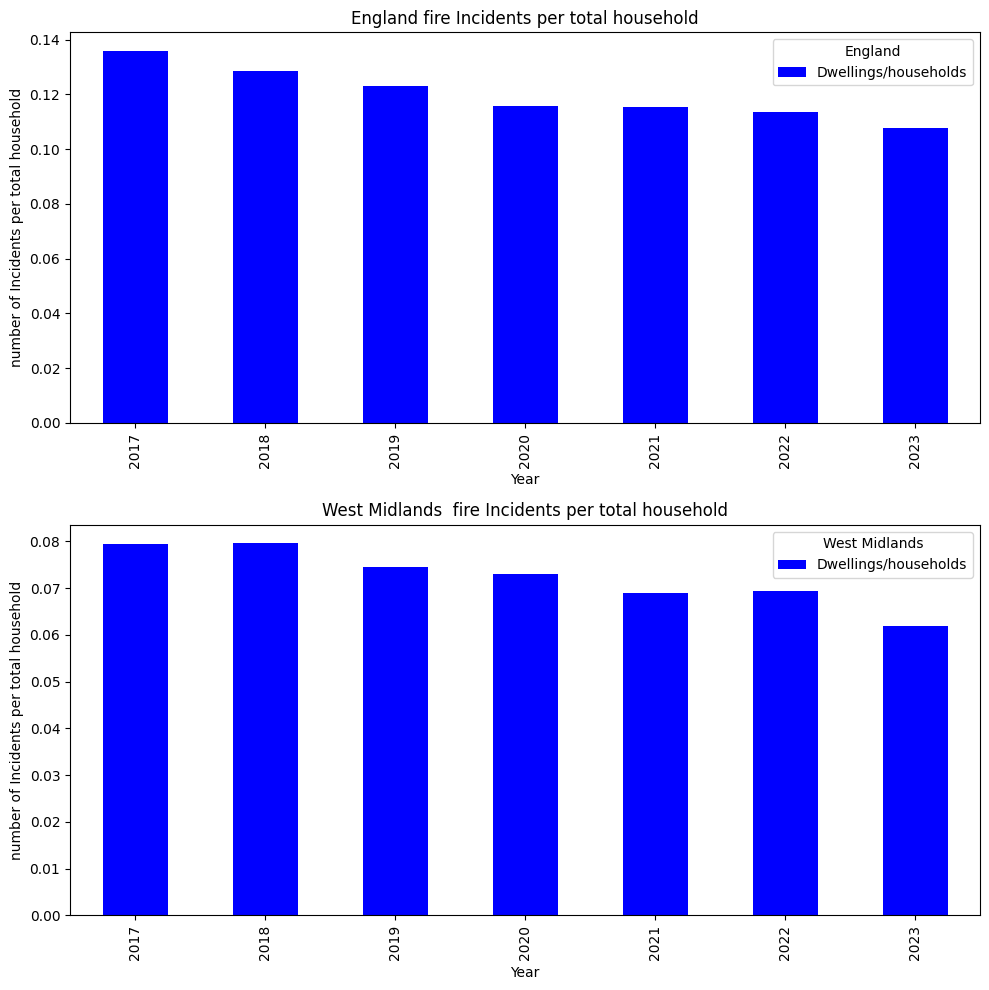

In [ ]:
# Plotting
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

# Plot for England
England_df.plot(
    x='Year',
    #y=['Total incidents/household', 'Total fires/households', 'Dwellings/households'],
    y=['Dwellings/households'],
    kind='bar',
    ax=axes[0],
    color=['blue', 'orange', 'green']
)
axes[0].set_title('England fire Incidents per total household')
axes[0].set_ylabel('number of Incidents per total household')
axes[0].legend(title='England')


# Plot for West Midlands
West_midlands_df.plot(
    x='Year',
    #y=['Total incidents/household', 'Total fires/households', 'Dwellings/households'],
    y=['Dwellings/households'],
    kind='bar',
    ax=axes[1],
    color=['blue', 'orange', 'green']
)
axes[1].set_title('West Midlands  fire Incidents per total household')
axes[1].set_ylabel('number of Incidents per total household')
axes[1].legend(title='West Midlands')

# Set x-axis labels
for ax in axes:
    ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

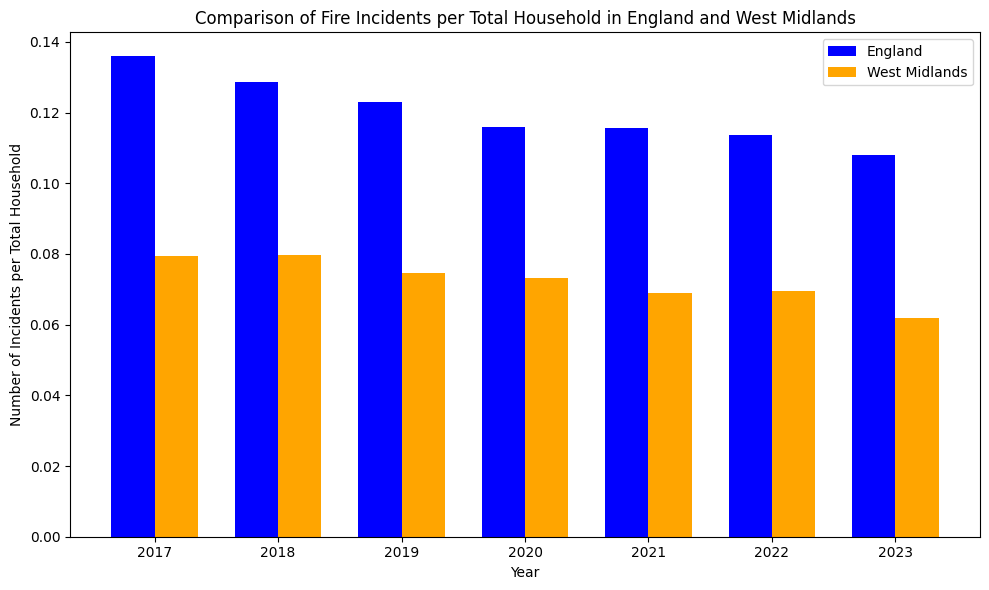

In [ ]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = np.arange(len(England_df['Year']))

# Plot for England
ax.bar(index, England_df['Dwellings/households'], bar_width, label='England', color='blue')

# Plot for West Midlands
ax.bar(index + bar_width, West_midlands_df['Dwellings/households'], bar_width, label='West Midlands', color='orange')

# Setting labels and titles
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents per Total Household')
ax.set_title('Comparison of Fire Incidents per Total Household in England and West Midlands')

# X-axis labels
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(England_df['Year'])

# Create legends
ax.legend()

# Show plot
plt.tight_layout()
plt.show()

In [ ]:
West_midlands_df

,Year,Total incidents/household,Total fires/households,Dwellings/households
0,2017,1.145817,0.454397,0.079408
1,2018,1.202929,0.502080,0.079584
2,2019,1.069456,0.379143,0.074567
3,2020,1.029654,0.390957,0.073075
4,2021,1.059465,0.358573,0.068991
5,2022,1.217319,0.431640,0.069484
6,2023,1.121289,0.332613,0.061905


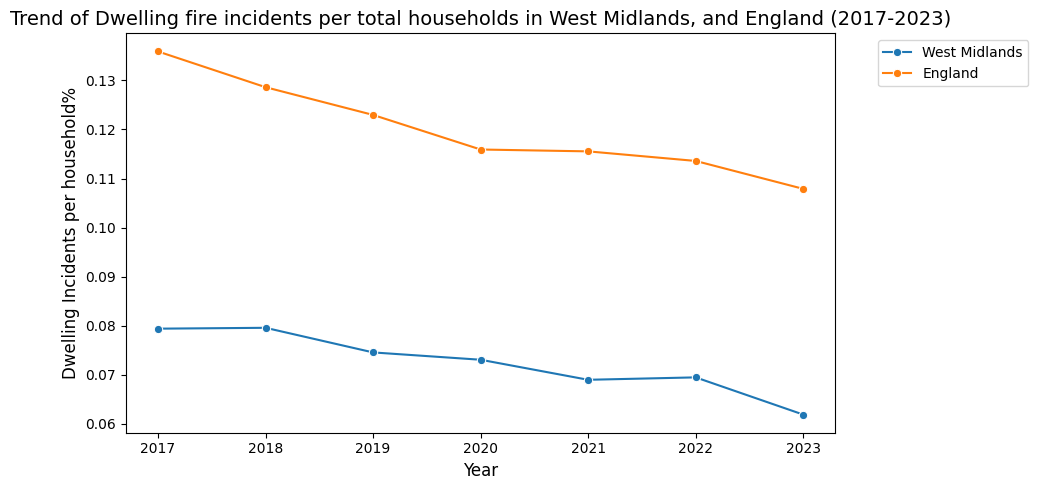

In [ ]:
# Plotting
plt.figure(figsize=(10, 5))

sns.lineplot(data=West_midlands_df, x='Year', y='Dwellings/households', marker='o', label='West Midlands')
sns.lineplot(data=England_df, x='Year', y='Dwellings/households', marker='o', label='England')

plt.title('Trend of Dwelling fire incidents per total households in West Midlands, and England (2017-2023)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Dwelling Incidents per household%', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


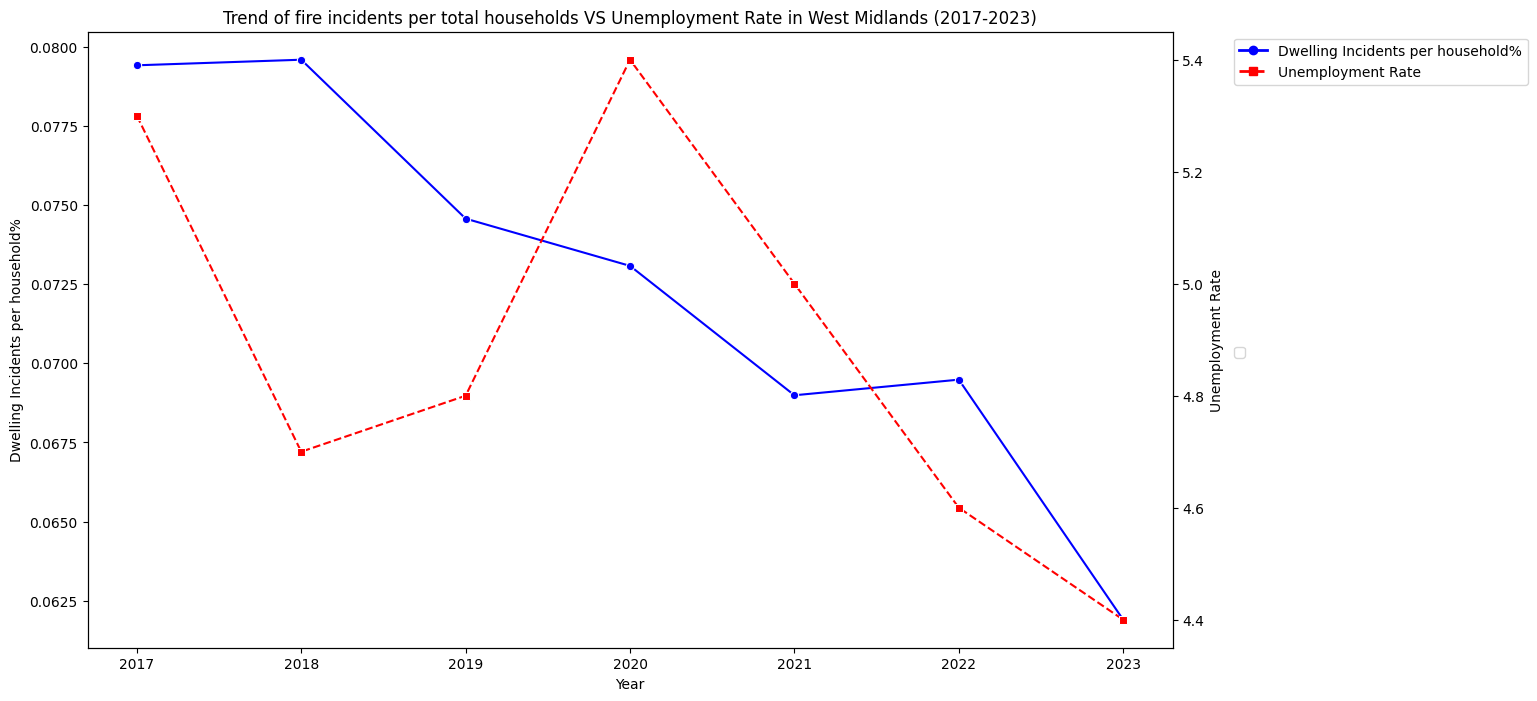

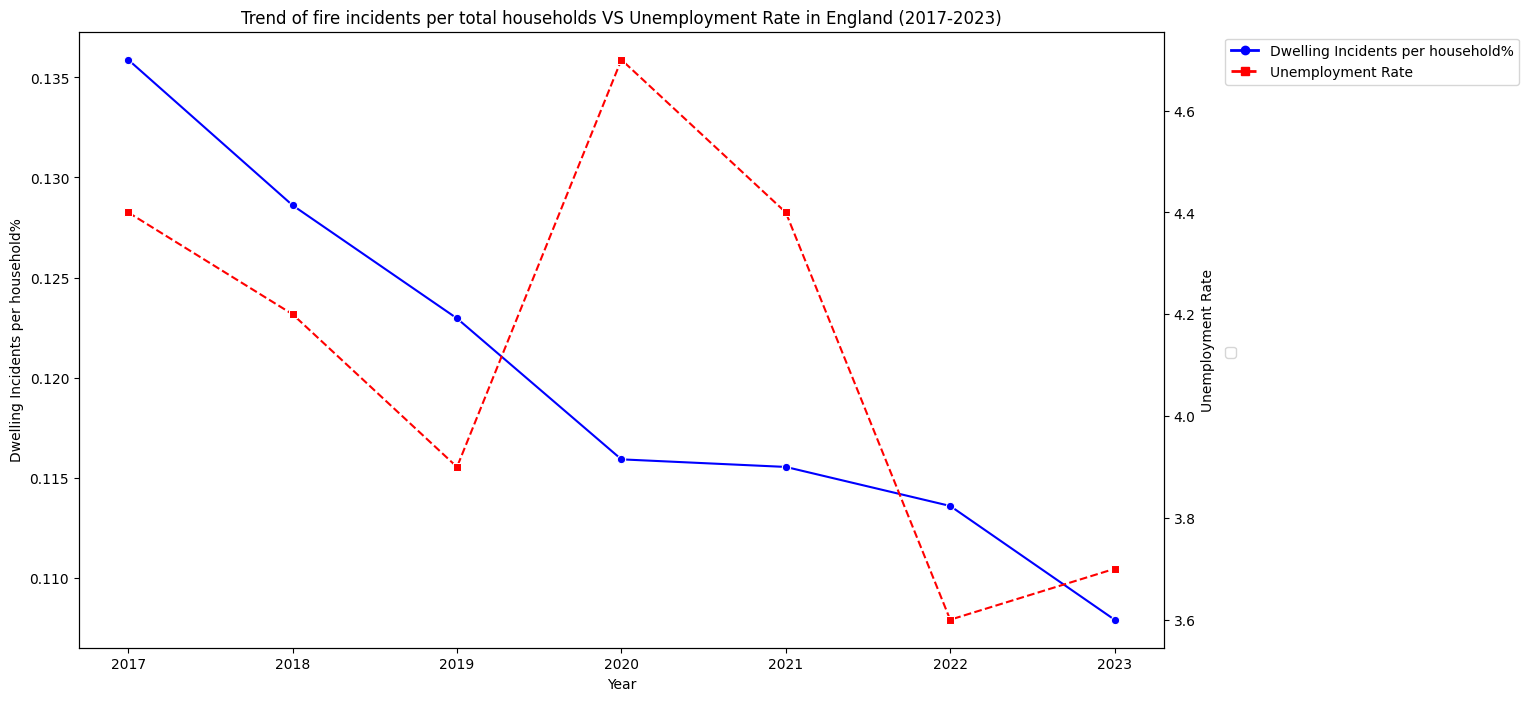

In [ ]:
# Plotting
#1-Plotting West midlands
fig, ax1 = plt.subplots(figsize=(14, 8))

sns.lineplot(data=West_midlands_df, x='Year', y='Dwellings/households', marker='o', linestyle='-', ax=ax1, color='blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Dwelling Incidents per household%')
ax1.set_title('Trend of fire incidents per total households VS Unemployment Rate in West Midlands (2017-2023)')


# Create a second y-axis for Unemployment Rate
ax2 = ax1.twinx()
sns.lineplot(data=filtered_unemployed, x='Date', y='West Midlands(%)', marker='s', linestyle='--', ax=ax2, color='red', legend=False)
ax2.set_ylabel('Unemployment Rate')

# Create custom legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
custom_lines = [plt.Line2D([0], [0], color='b', lw=2, linestyle='-', marker='o'),
                plt.Line2D([0], [0], color='r', lw=2, linestyle='--', marker='s')]
ax2.legend(custom_lines, ['Dwelling Incidents per household%', 'Unemployment Rate'], loc='upper left', bbox_to_anchor=(1.05, 1))
ax1.legend(handles1, labels1, loc='upper left', bbox_to_anchor=(1.05, 0.5))
plt.show()


#sns.lineplot(data=west_midlands_data, x='Year', y='Dwellings', marker='o', label='Dwelling incidents')
#sns.lineplot(data=filtered_england_data, x='Year', y='Dwellings', marker='o', label='Great Britain')

#plt.title('Trend of Dwelling fire incidents VS in West Midlands (2017-2023)', fontsize=14)
#plt.xlabel('Year', fontsize=12)
#plt.ylabel('Dwelling Incidents (thousands)', fontsize=12)

#2-Plotting Greate Britain
fig, ax1 = plt.subplots(figsize=(14, 8))
sns.lineplot(data=England_df, x='Year', y='Dwellings/households', marker='o', linestyle='-', ax=ax1, color='blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Dwelling Incidents per household%')
ax1.set_title('Trend of fire incidents per total households VS Unemployment Rate in England (2017-2023)')

# Create a second y-axis for Unemployment Rate
ax2 = ax1.twinx()
sns.lineplot(data=filtered_unemployed, x='Date', y='Great Britain(%)', marker='s', linestyle='--', ax=ax2, color='red', legend=False)
ax2.set_ylabel('Unemployment Rate')

# Create custom legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
custom_lines = [plt.Line2D([0], [0], color='b', lw=2, linestyle='-', marker='o'),
                plt.Line2D([0], [0], color='r', lw=2, linestyle='--', marker='s')]
ax2.legend(custom_lines, ['Dwelling Incidents per household%', 'Unemployment Rate'], loc='upper left', bbox_to_anchor=(1.05, 1))
ax1.legend(handles1, labels1, loc='upper left', bbox_to_anchor=(1.05, 0.5))
plt.show()